# 01 — Хайгуулын дата шинжилгээ (EDA): ZMS/HUR зээлийн эрсдэл

**Зорилго.** Энэ notebook нь моделчлал эхлэхээс өмнө датаг "танихад" зориулагдсан.
Бид дараах асуултуудад хариулна: дата ямар бүтэцтэй вэ, дутуу утга хаана их вэ,
эрсдэл (30+ DPD) хэн дээр өндөр вэ, аль хувьсагч таамаглах чадвар сайтай вэ.

**Дата.** `data/ZMS_HUR_data_new.xlsx` (Sheet2). `config.load_data()` нь
HUR/ZMS аль алинд хамаарахгүй (`hashur=0 & haszms=0`) харилцагчдыг хасч,
**39,242 харилцагч** үлдээнэ.

**Таргет.** `30` = зээлээ 30+ хоног хугацаа хэтрүүлсэн эсэх (1=муу, 0=сайн).
Нэмэлт таргет `before_first_close_30+`.

**Сегмент** (`hashur`, `haszms`-аас): `both`, `hur_only`, `zms_only`.

**Хэмжүүр.** IV (Information Value) — нэг хувьсагч сайн/муугийн ялгааг хэр сайн
заадгийн хэмжүүр: <0.02 хэрэггүй, 0.02–0.1 сул, 0.1–0.3 дунд, >0.3 хүчтэй.

> ⚠️ **Leakage-аас сэргийлэх.** IV болон бусад сонголтыг ЗӨВХӨН `train` хэсэг
> дээр тооцоолно. `make_split` нь бүх notebook-д ИЖИЛ хуваалт өгдөг.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import config, features, feature_selection as fs

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Дата ачаалах + FE
df = config.load_data()
df = features.engineer_features(df)
df['segment'] = df.apply(config.assign_segment, axis=1)
df['age_grp'] = pd.cut(df['age'], bins=[17,22,25,30,35,45,100],
                       labels=['18-22','23-25','26-30','31-35','36-45','46+'])
print(f"Shape: {df.shape}")
df.head(3)

[load_data] neither хасав: 57,127 → 39,242 (17,885 мөр хасагдсан)


Shape: (39242, 109)


,cust_code,gender,age,city_name,hashur,haszms,30,before_first_close_30+,salary_last_amt,salary_avg_3m,...,fe_salary_gap,fe_org_churn,fe_recency,fe_loan_velocity,fe_short_term_reliance,fe_normal_ratio,fe_closed_ratio,fe_collateral_burden,segment,age_grp
0,1020000004,1,29,ОРХОН-TOTAL,0,1,0,0,NaN,NaN,...,0.0,0.0,70.0,0.417939,0.00,0.333333,0.000000,0.666667,zms_only,26-30
1,1020000036,0,44,УЛААНБААТАР-ХАН-УУЛ,0,1,0,0,NaN,NaN,...,0.0,0.0,30.0,4.347488,0.82,0.913043,0.941176,0.086957,zms_only,36-45
2,1020000113,1,29,УЛААНБААТАР-БАЯНЗҮРХ,1,1,0,0,0.0,0.0,...,6.0,2.0,239.0,5.936624,0.55,0.931034,0.850000,0.068966,both,26-30


### Дата ачаалал ба нэг удаагийн хуваалт

`config.load_data()` → `features.feature_engineering()` → сегмент онооно.
Дараа нь `config.make_split(df)` нь датаг **80% train / 20% test** болгон
хуваана (PRIMARY таргетаар stratify). Энэ ИЖИЛ хуваалтыг 02–04 NB бүгд
ашигладаг тул моделуудыг шударгаар харьцуулна.

In [2]:
PRIMARY = config.PRIMARY_TARGET

# НЭГ удаагийн нийтлэг train/test хуваалт (бүх NB ижил хуваалтыг ашиглана)
df['is_test'] = config.make_split(df)
df_train, df_test = df[~df['is_test']], df[df['is_test']]
print(f"Train: {len(df_train):,}  Test: {len(df_test):,}")
print(f"Train bad rate ({PRIMARY}): {df_train[PRIMARY].mean()*100:.1f}%  "
      f"Test: {df_test[PRIMARY].mean()*100:.1f}%")

Train: 31,393  Test: 7,849
Train bad rate (30): 12.9%  Test: 12.9%


## Хувьсагчийн толь (Data Dictionary)

Энд (1) **аль баганыг яагаад хассан**, (2) **feature engineering-ээр шинээр
үүсгэсэн `fe_*` хувьсагч бүрийн утга/томьёо** болон тэдгээрийн IV-г харуулна.
Хасах болон шинээр үүсгэх логик бүхэлдээ `src/`-д төвлөрсөн (NB-д давхардуулахгүй).

In [3]:
from feature_selection import compute_iv, iv_label

# 1) Хасагдсан баганууд ба шалтгаан
dropped = pd.DataFrame([
    ("cust_code", "ID", "Харилцагчийн дугаар — зөвхөн таних. Таамаглах чадваргүй."),
    ("actor_id / scr_id / scr_calc_at", "ID/огноо", "Хуучин датанд байсан, шинэ датанд алга (автомат алгасна)."),
    ("first_loan_date / last_loan_date", "огноо", "Шинэ датанд байхгүй."),
    ("30", "ТАРГЕТ", "Таамаглах зорилт. Фичер болговол data leakage."),
    ("before_first_close_30+", "ТАРГЕТ", "Нэмэлт таргет."),
    ("neither (hashur=0 & haszms=0)", "популяци", "HUR/ZMS аль алинд хамаарахгүй 17,885 мөр — скоринг популяциас хасав."),
    ("city_name", "категори", "75 ангитай (high cardinality) — оронд нь zone (14 анги) ашиглана."),
    ("hashur / haszms", "flag", "Оронд нь has_hur / has_zms flag ашиглана (давхардлаас сэргийлэв)."),
], columns=["Багана / Шүүлт", "Төрөл", "Яагаад хасав"])
print("─── ХАСАГДСАН ───")
print(dropped.to_string(index=False))

# 2) fe_* фичерүүдийн утга/томьёо
fe_desc = {
    "fe_dti_line":          "line үлдэгдэл / 6с цалин — банк/зээлийн шугамын өрийн ачаалал",
    "fe_dti_ln":            "ln нээлттэй үлдэгдэл / 6с цалин — ББСБ зээлийн өрийн ачаалал",
    "fe_dti_total":         "(line+ln үлдэгдэл) / 6с цалин — НИЙТ өрийн ачаалал",
    "fe_payment_burden":    "ZMS сарын төлбөр / 3с цалин — сарын төлбөрийн дарамт",
    "fe_bbsb_ratio":        "ББСБ зээлдүүлэгч / нийт зээлдүүлэгч",
    "fe_overdue_ratio":     "хугацаа хэтэрсэн зээл / нийт зээл",
    "fe_loan_per_org":      "нийт зээл / байгууллагын тоо — давтан зээлдэлт",
    "fe_maxconc_to_sal":    "хамгийн том зээл / 6с цалин — концентраци",
    "fe_avg_loan_to_sal":   "дундаж зээл / 6с цалин",
    "fe_open_arr_ratio":    "идэвхтэй хугацаа хэтрэлттэй зээл / нийт",
    "fe_overdue_x_util":    "хэтрэлт × ашиглалт (interaction)",
    "fe_dpd_recent_flag":   "сүүлийн 12 сард DPD гарсан эсэх (0/1)",
    "fe_ever_overdue":      "урьд хэзээ нэгэн цагт хэтрүүлсэн харьцаа",
    "fe_total_util":        "нээлттэй үлдэгдэл / (нээлттэй+хаасан) — ашиглалт",
    "fe_balance_to_sal":    "нийт нээлттэй үлдэгдэл / 6с цалин",
    "fe_bank_share":        "банк зээлдүүлэгч / нийт зээлдүүлэгч",
    "fe_lenders_per_loan":  "зээлдүүлэгч / зээл — олон эх үүсвэр",
    "fe_salary_instability":"цалингийн хэлбэлзэл (CV 6 сар)",
    "fe_salary_gap":        "цалин ороогүй саруудын тоо",
    "fe_org_churn":         "24 сард ажил солисон тоо",
    "fe_recency":           "сүүлийн зээлээс хойшхи хоног",
    "fe_loan_velocity":     "жилд авсан зээлийн тоо (эргэлт)",
    "fe_short_term_reliance":"богино хугацаат зээлийн хамаарал",
    "fe_normal_ratio":      "хэвийн зээл / нийт — багцын чанар",
    "fe_closed_ratio":      "хаасан зээл / нийт ln — туршлага",
    "fe_collateral_burden": "(барьцаа+авлага) / нийт зээл",
}

df_tr = df[~df['is_test']]              # IV-г ЗӨВХӨН train дээр (leakage-гүй)
rows = []
for k, v in fe_desc.items():
    iv = compute_iv(df_tr, k, PRIMARY) if k in df_tr.columns else float('nan')
    rows.append((k, round(iv, 3), iv_label(iv), v))
fe_tbl = pd.DataFrame(rows, columns=["fe фичер", "IV", "Хүч", "Утга / томьёо"])            .sort_values("IV", ascending=False).reset_index(drop=True)
print("\n─── ШИНЭ fe_* ФИЧЕРҮҮД (train IV-ээр эрэмбэлсэн) ───")
print(fe_tbl.to_string(index=False))

─── ХАСАГДСАН ───
                  Багана / Шүүлт    Төрөл                                                         Яагаад хасав
                       cust_code       ID             Харилцагчийн дугаар — зөвхөн таних. Таамаглах чадваргүй.
 actor_id / scr_id / scr_calc_at ID/огноо            Хуучин датанд байсан, шинэ датанд алга (автомат алгасна).
first_loan_date / last_loan_date    огноо                                                 Шинэ датанд байхгүй.
                              30   ТАРГЕТ                       Таамаглах зорилт. Фичер болговол data leakage.
          before_first_close_30+   ТАРГЕТ                                                       Нэмэлт таргет.
   neither (hashur=0 & haszms=0) популяци HUR/ZMS аль алинд хамаарахгүй 17,885 мөр — скоринг популяциас хасав.
                       city_name категори    75 ангитай (high cardinality) — оронд нь zone (14 анги) ашиглана.
                 hashur / haszms     flag    Оронд нь has_hur / has_zms flag ашиглана (давхард


─── ШИНЭ fe_* ФИЧЕРҮҮД (train IV-ээр эрэмбэлсэн) ───
              fe фичер    IV     Хүч                                                 Утга / томьёо
       fe_loan_per_org 0.121  Medium                нийт зээл / байгууллагын тоо — давтан зээлдэлт
   fe_lenders_per_loan 0.087    Weak                           зээлдүүлэгч / зээл — олон эх үүсвэр
         fe_bank_share 0.086    Weak                           банк зээлдүүлэгч / нийт зээлдүүлэгч
      fe_loan_velocity 0.085    Weak                               жилд авсан зээлийн тоо (эргэлт)
           fe_dti_line 0.084    Weak line үлдэгдэл / 6с цалин — банк/зээлийн шугамын өрийн ачаалал
       fe_normal_ratio 0.080    Weak                             хэвийн зээл / нийт — багцын чанар
  fe_collateral_burden 0.074    Weak                                  (барьцаа+авлага) / нийт зээл
       fe_closed_ratio 0.059    Weak                              хаасан зээл / нийт ln — туршлага
         fe_total_util 0.052    Weak              нээлт

## 1. Дутуу утга (Nulls)

Дутуу утгын хувь баганаар. 50%-аас дээш дутуутай баганууд (улаан зураас) ихэвчлэн цалингийн мэдээлэлтэй холбоотой — цалингийн эх сурвалжгүй харилцагчдад үүснэ.

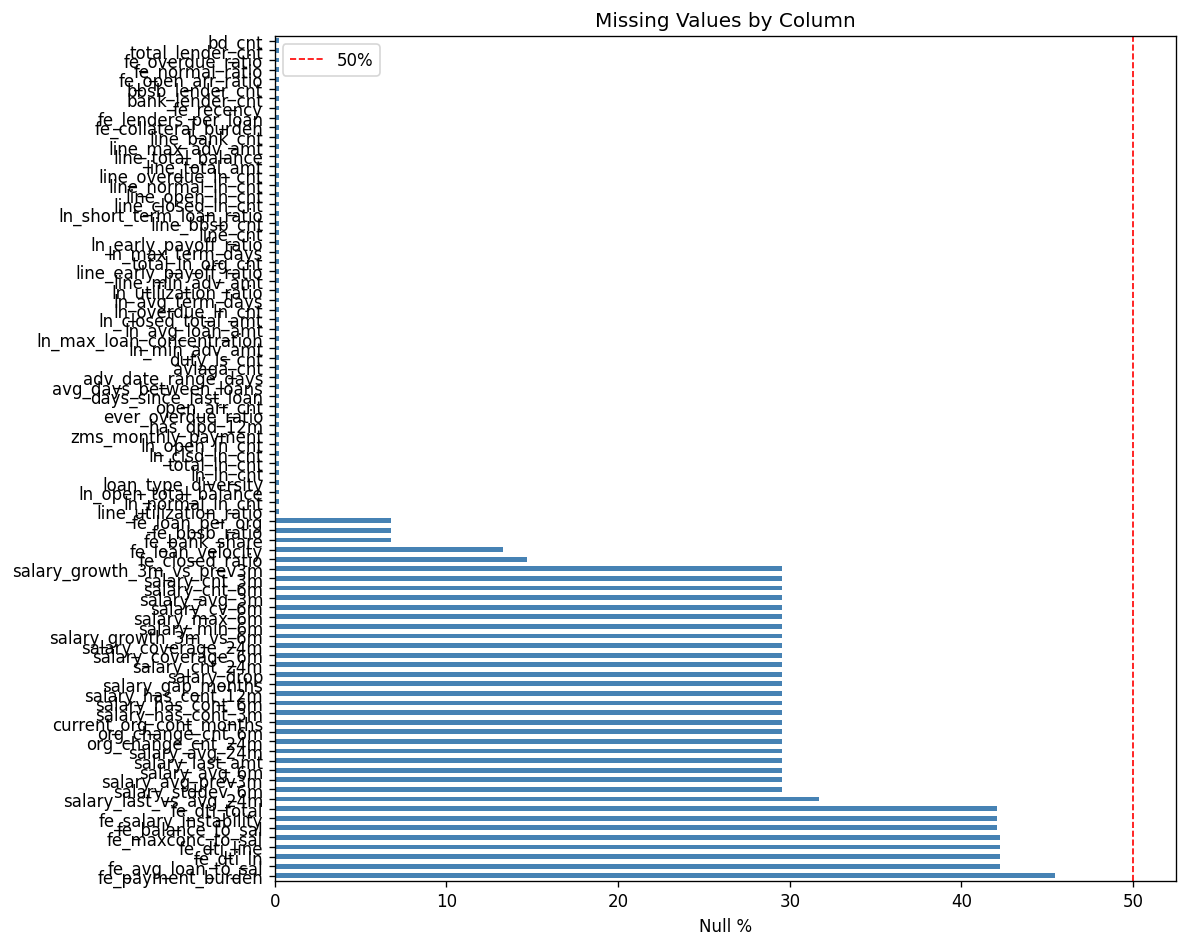

Columns >50% null: 0
Columns 0 null:    22


In [4]:
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, 8))
null_pct.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50%')
ax.set_xlabel('Null %'); ax.set_title('Missing Values by Column'); ax.legend()
plt.tight_layout(); plt.show()

print(f"Columns >50% null: {(null_pct > 50).sum()}")
print(f"Columns 0 null:    {(df.isnull().sum() == 0).sum()}")

## 2. Сегментийн тархалт

Сегмент бүр өөр эрсдэлийн профайлтай: `both` (HUR+ZMS хоёулаа) хамгийн бага эрсдэлтэй, `zms_only` хамгийн өндөр. Тиймээс 03 NB сегмент бүрд тусдаа модель сургадаг.

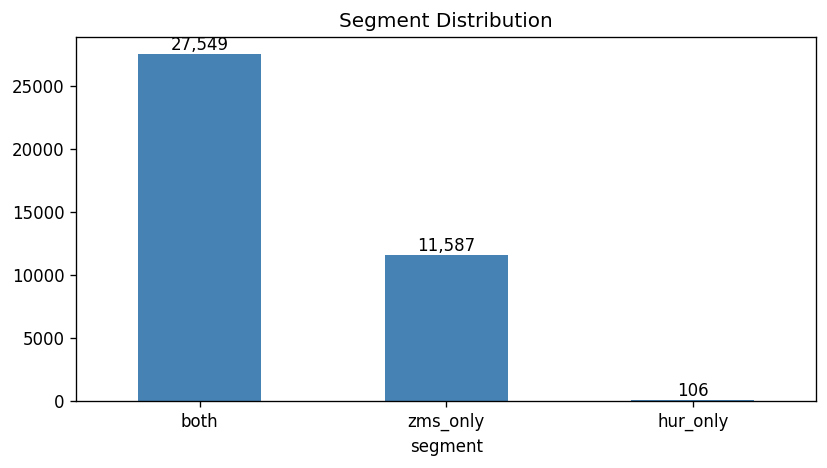

segment
both        27549
zms_only    11587
hur_only      106
Name: count, dtype: int64


In [5]:
seg_counts = df['segment'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
seg_counts.plot(kind='bar', ax=ax, color='steelblue', rot=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
ax.set_title('Segment Distribution'); plt.tight_layout(); plt.show()
print(seg_counts)

## 3. Таргетын тархалт

Таргетын тэнцвэргүй байдал (bad rate ~13%) — энэ нь хэт туйлширсан биш тул `class_weight` хангалттай (хэт SMOTE шаардлагагүй).

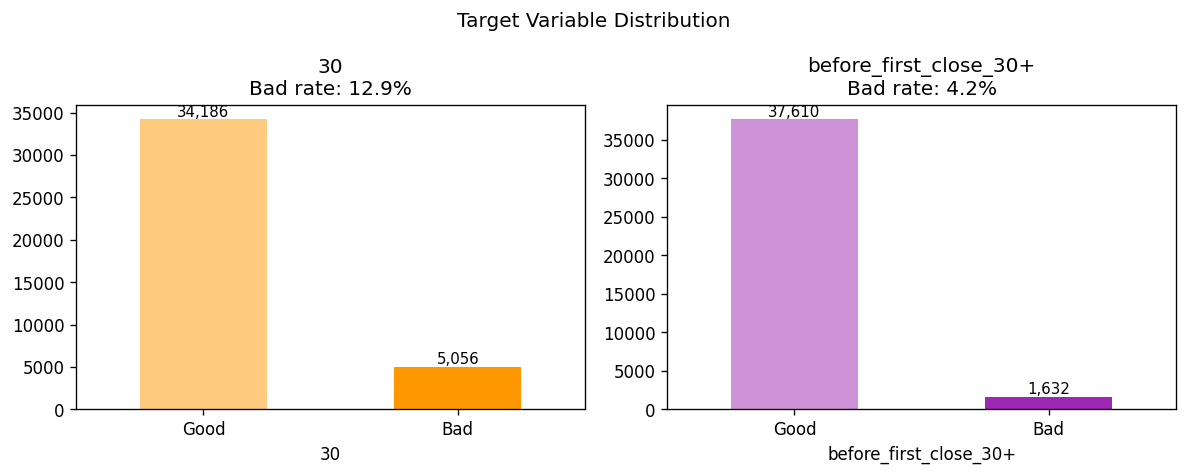

In [6]:
colors = ['#FF9800', '#9C27B0']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, cc in zip(axes, config.TARGETS, colors):
    vc = df[col].value_counts().sort_index()
    vc.plot(kind='bar', ax=ax, color=[cc+'80', cc], rot=0)
    ax.set_title(f'{col}\nBad rate: {df[col].mean()*100:.1f}%')
    ax.set_xticklabels(['Good','Bad'])
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,.0f}',
                    (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Target Variable Distribution'); plt.tight_layout(); plt.show()

## 4. Хүн ам зүй — Нас & Хүйс

Нас залуу болон зарим хүйсийн бүлэгт bad rate өндөр эсэхийг шалгана — энэ нь хүн ам зүйн фичерийн ач холбогдлыг харуулна.

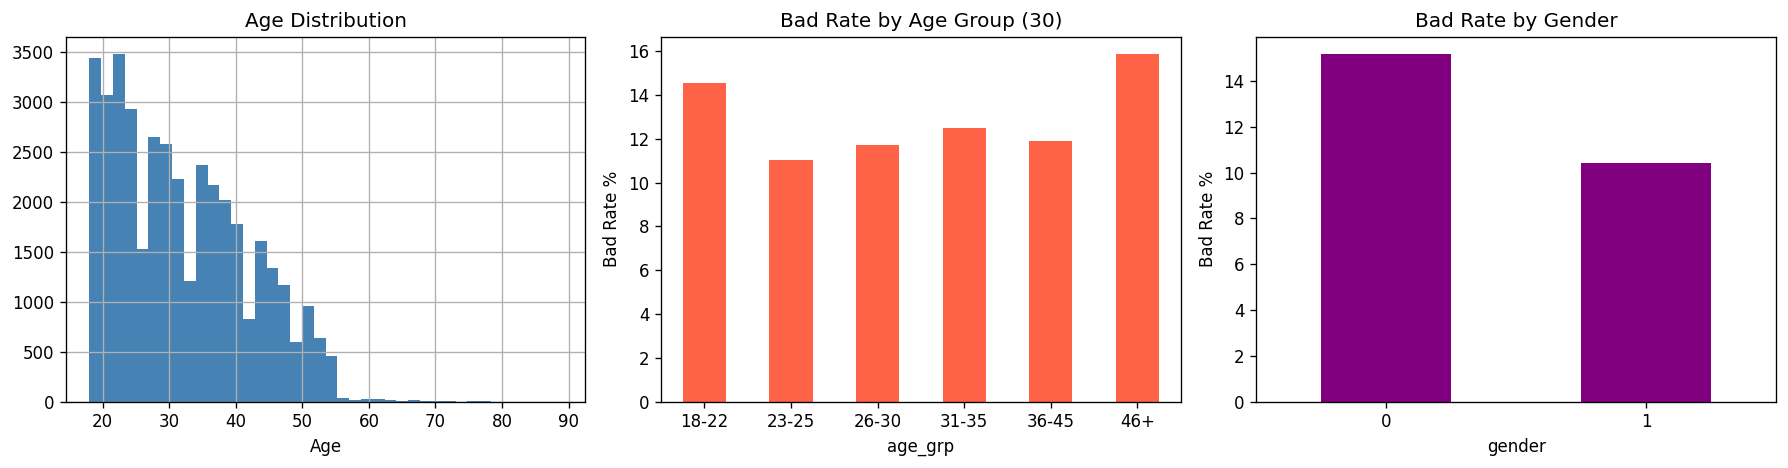

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['age'].hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution'); axes[0].set_xlabel('Age')

age_bad = df.groupby('age_grp', observed=True)[config.PRIMARY_TARGET].mean()*100
age_bad.plot(kind='bar', ax=axes[1], color='tomato', rot=0)
axes[1].set_title(f'Bad Rate by Age Group ({config.PRIMARY_TARGET})')
axes[1].set_ylabel('Bad Rate %')

gen_bad = df.groupby('gender')[config.PRIMARY_TARGET].mean()*100
gen_bad.plot(kind='bar', ax=axes[2], color='purple', rot=0)
axes[2].set_title('Bad Rate by Gender'); axes[2].set_ylabel('Bad Rate %')
plt.tight_layout(); plt.show()

## 5. Хотын тархалт (топ 15)

`city_name` нь 75 ангитай (high cardinality) тул модельд шууд тохиромжгүй. Иймд `features.py`-д **`zone` (14 анги)** үүсгэв: 5 хөдөөгийн бүс (Баруун, Хангай, Төв, Зүүн, Говь) + Улаанбаатарын 9 дүүрэг. Модель `zone`-г ашиглана — NB02-д WoE категори, NB03/04-д target encoding (one-hot-той харьцуулсан).

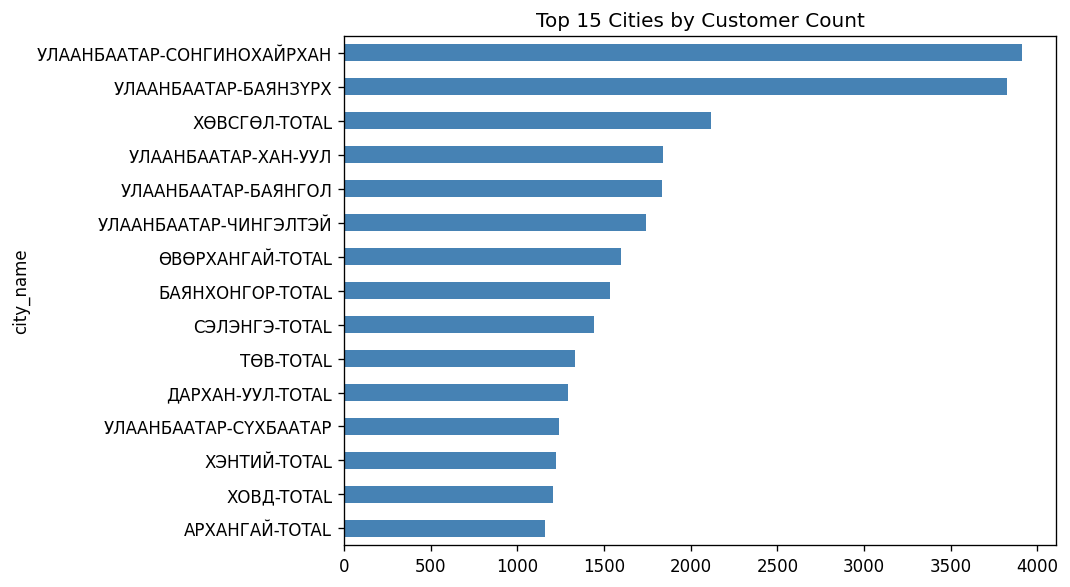

In [8]:
top_cities = df['city_name'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 5))
top_cities.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Cities by Customer Count'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 6. Цалин & Зээлийн feature-үүд

Цалин/зээлийн хуваарилалтыг 1–99 перцентилээр тайрч (outlier-ийн нөлөөг бууруулж) харуулна.

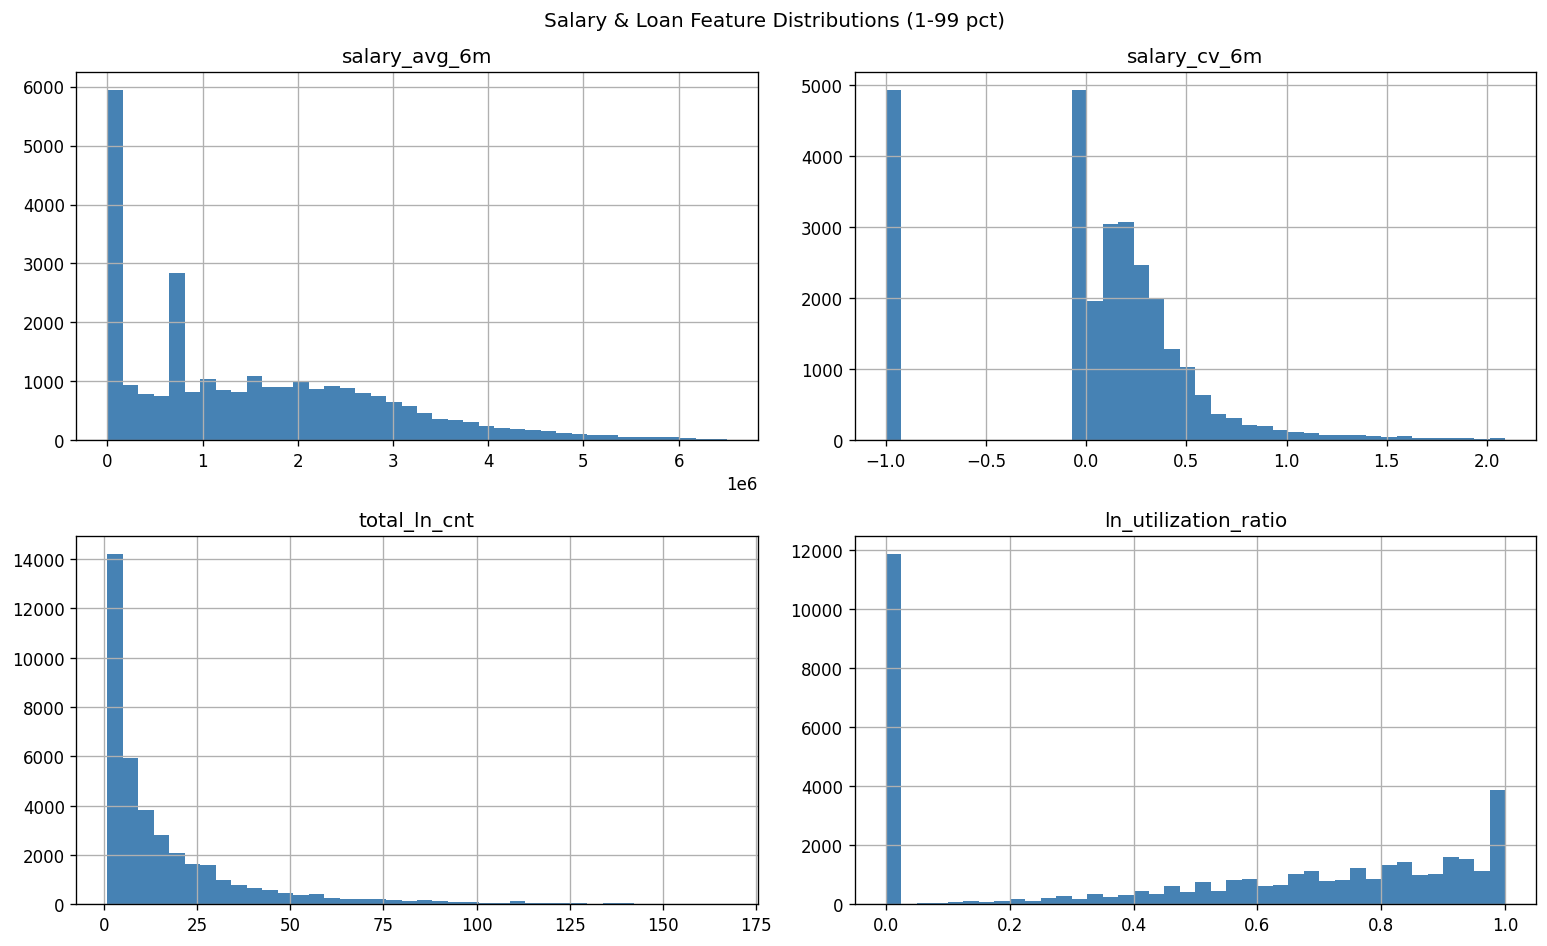

In [9]:
sal_cols  = ['salary_avg_6m','salary_cv_6m']
loan_cols = ['total_ln_cnt','ln_utilization_ratio']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), sal_cols+loan_cols):
    d = df[col].dropna()
    d = d[d.between(d.quantile(0.01), d.quantile(0.99))]
    d.hist(bins=40, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Salary & Loan Feature Distributions (1-99 pct)')
plt.tight_layout(); plt.show()

## 7. Information Value (IV) — Feature Selection

IV-г **train split дээр** тооцоолно. Босго: <0.02 хэрэггүй, 0.02-0.1 сул,
0.1-0.3 дунд, >0.3 хүчтэй.

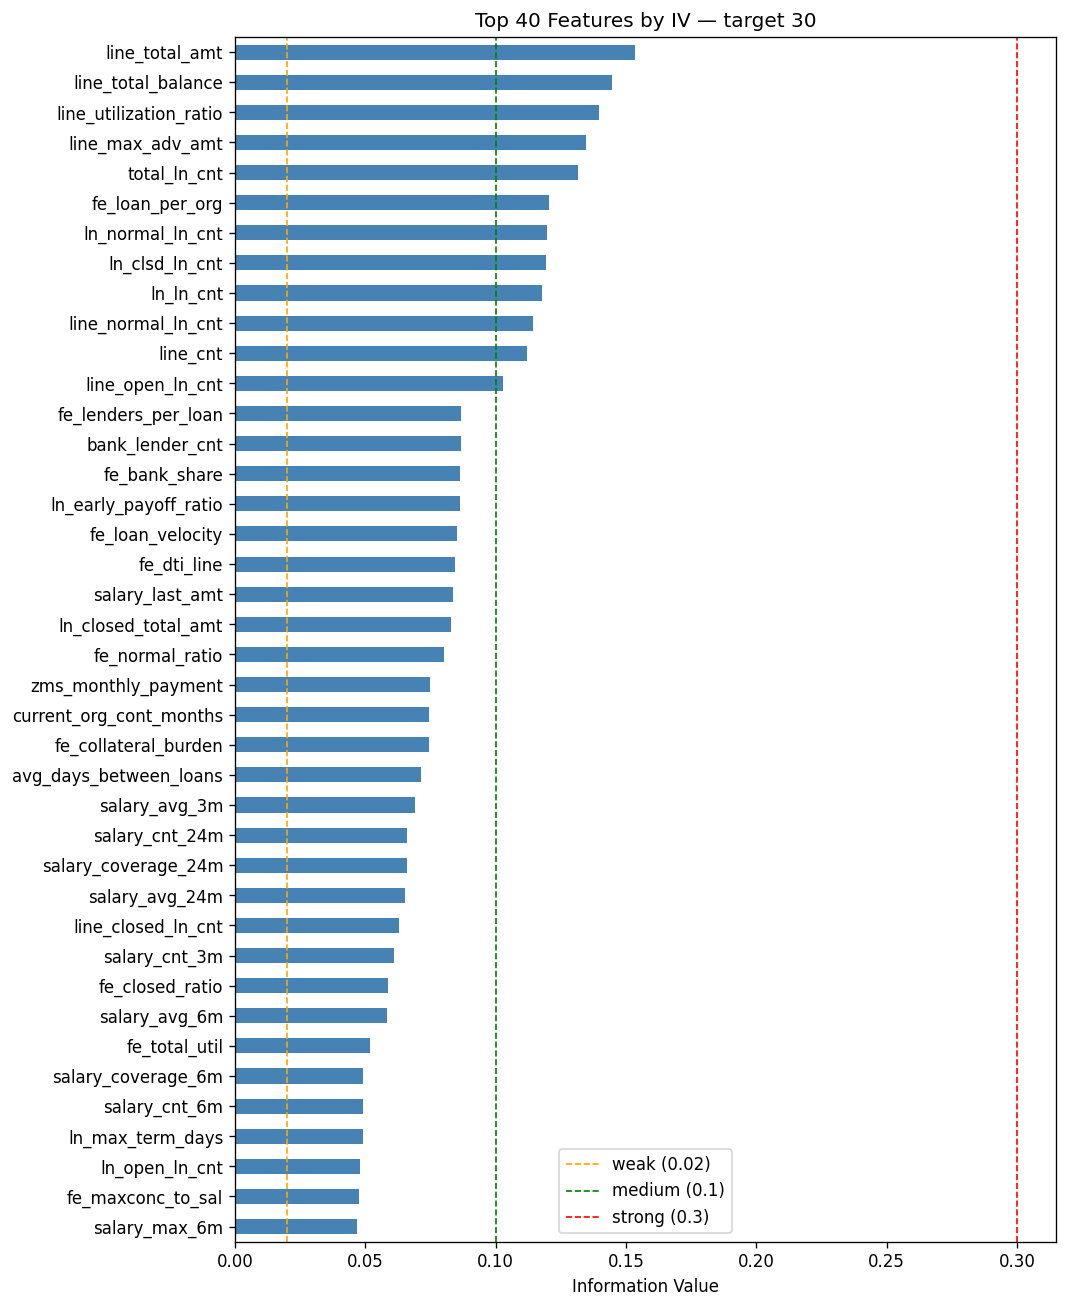

Selected after IV+corr filter: 51
line_total_amt            0.153439
line_total_balance        0.144600
line_utilization_ratio    0.139608
line_max_adv_amt          0.134814
total_ln_cnt              0.131682
fe_loan_per_org           0.120569
ln_normal_ln_cnt          0.119799
ln_clsd_ln_cnt            0.119241
ln_ln_cnt                 0.117916
line_normal_ln_cnt        0.114198
line_cnt                  0.112108
line_open_ln_cnt          0.102954
fe_lenders_per_loan       0.086805
bank_lender_cnt           0.086571
fe_bank_share             0.086252


In [10]:
feat_cols = config.feature_columns(df)
sel, iv = fs.select_features(df_train, feat_cols, config.PRIMARY_TARGET,
                            categorical=tuple(config.CATEGORICAL_VARS))

iv_s = pd.Series(iv).sort_values(ascending=False)
iv_top = iv_s.head(40)

fig, ax = plt.subplots(figsize=(9, 11))
iv_top[::-1].plot(kind='barh', ax=ax, color='steelblue')
for thr, lbl, cl in [(0.02,'weak','orange'),(0.1,'medium','green'),(0.3,'strong','red')]:
    ax.axvline(thr, ls='--', lw=1, color=cl, label=f'{lbl} ({thr})')
ax.set_title(f'Top 40 Features by IV — target {config.PRIMARY_TARGET}')
ax.set_xlabel('Information Value'); ax.legend()
plt.tight_layout(); plt.show()

print(f"Selected after IV+corr filter: {len(sel)}")
print(iv_s.head(15).to_string())

## Шинэ фичерүүдийн эрсдэл ялгах чадвар

IV тоо нэг утга өгдөг ч, фичер хэрхэн ажилладгийг **decile (10 хуваалт) тус
бүрийн bad rate**-аар харвал ойлгомжтой. Сайн фичерийн хувьд багана зүүнээс
баруун тийш жигд өсөх/буурах (монотон) хандлагатай байх ёстой — энэ нь
scorecard-д WoE хэлбэрээр ашиглахад тохиромжтойг илтгэнэ.

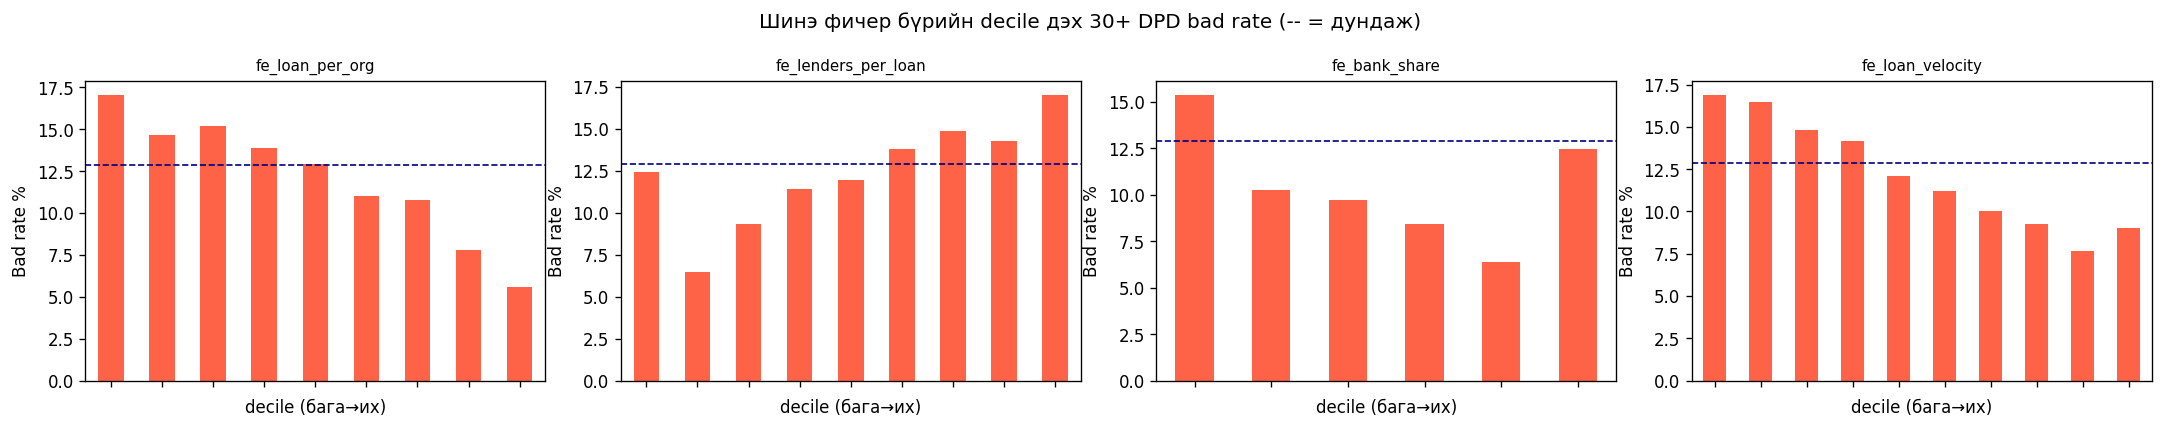

In [11]:
import numpy as np
top_fe = [c for c in fe_tbl['fe фичер'] if c in df.columns][:4]
fig, axes = plt.subplots(1, len(top_fe), figsize=(4.5*len(top_fe), 3.6))
for ax, feat in zip(np.atleast_1d(axes), top_fe):
    tmp = df_tr[[feat, PRIMARY]].dropna().copy()
    tmp['decile'] = pd.qcut(tmp[feat], 10, duplicates='drop')
    br = tmp.groupby('decile', observed=True)[PRIMARY].mean() * 100
    br.plot(kind='bar', ax=ax, color='tomato')
    ax.axhline(df_tr[PRIMARY].mean()*100, color='navy', ls='--', lw=1)
    ax.set_title(feat, fontsize=9)
    ax.set_xticklabels([]); ax.set_ylabel('Bad rate %'); ax.set_xlabel('decile (бага→их)')
plt.suptitle('Шинэ фичер бүрийн decile дэх 30+ DPD bad rate (-- = дундаж)')
plt.tight_layout(); plt.show()

## 8. IV — бүх таргетаар харьцуулах

In [12]:
rows = {}
for t in config.TARGETS:
    _, iv_t = fs.select_features(df_train, feat_cols, t)
    rows[t] = pd.Series(iv_t)
iv_table = pd.DataFrame(rows).fillna(0)
iv_table['max'] = iv_table.max(axis=1)
iv_table = iv_table.sort_values('max', ascending=False).drop(columns='max')
print(iv_table.head(20).round(3).to_string())

                           30  before_first_close_30+
line_total_amt          0.153                   0.165
line_total_balance      0.145                   0.154
line_max_adv_amt        0.135                   0.149
line_utilization_ratio  0.140                   0.127
line_cnt                0.112                   0.138
line_normal_ln_cnt      0.114                   0.138
total_ln_cnt            0.132                   0.138
fe_loan_per_org         0.121                   0.058
ln_normal_ln_cnt        0.120                   0.097
ln_clsd_ln_cnt          0.119                   0.096
ln_ln_cnt               0.118                   0.097
line_open_ln_cnt        0.103                   0.113
age                     0.035                   0.107
fe_dti_line             0.084                   0.106
total_ln_org_cnt        0.035                   0.095
total_lender_cnt        0.035                   0.095
salary_last_amt         0.084                   0.091
fe_lenders_per_loan     0.08

## 9. Корреляцийн матриц (multicollinearity)

Харилцан хамаарал (|r|) өндөр хосуудаас IV бага талыг хасч multicollinearity-г бууруулна.

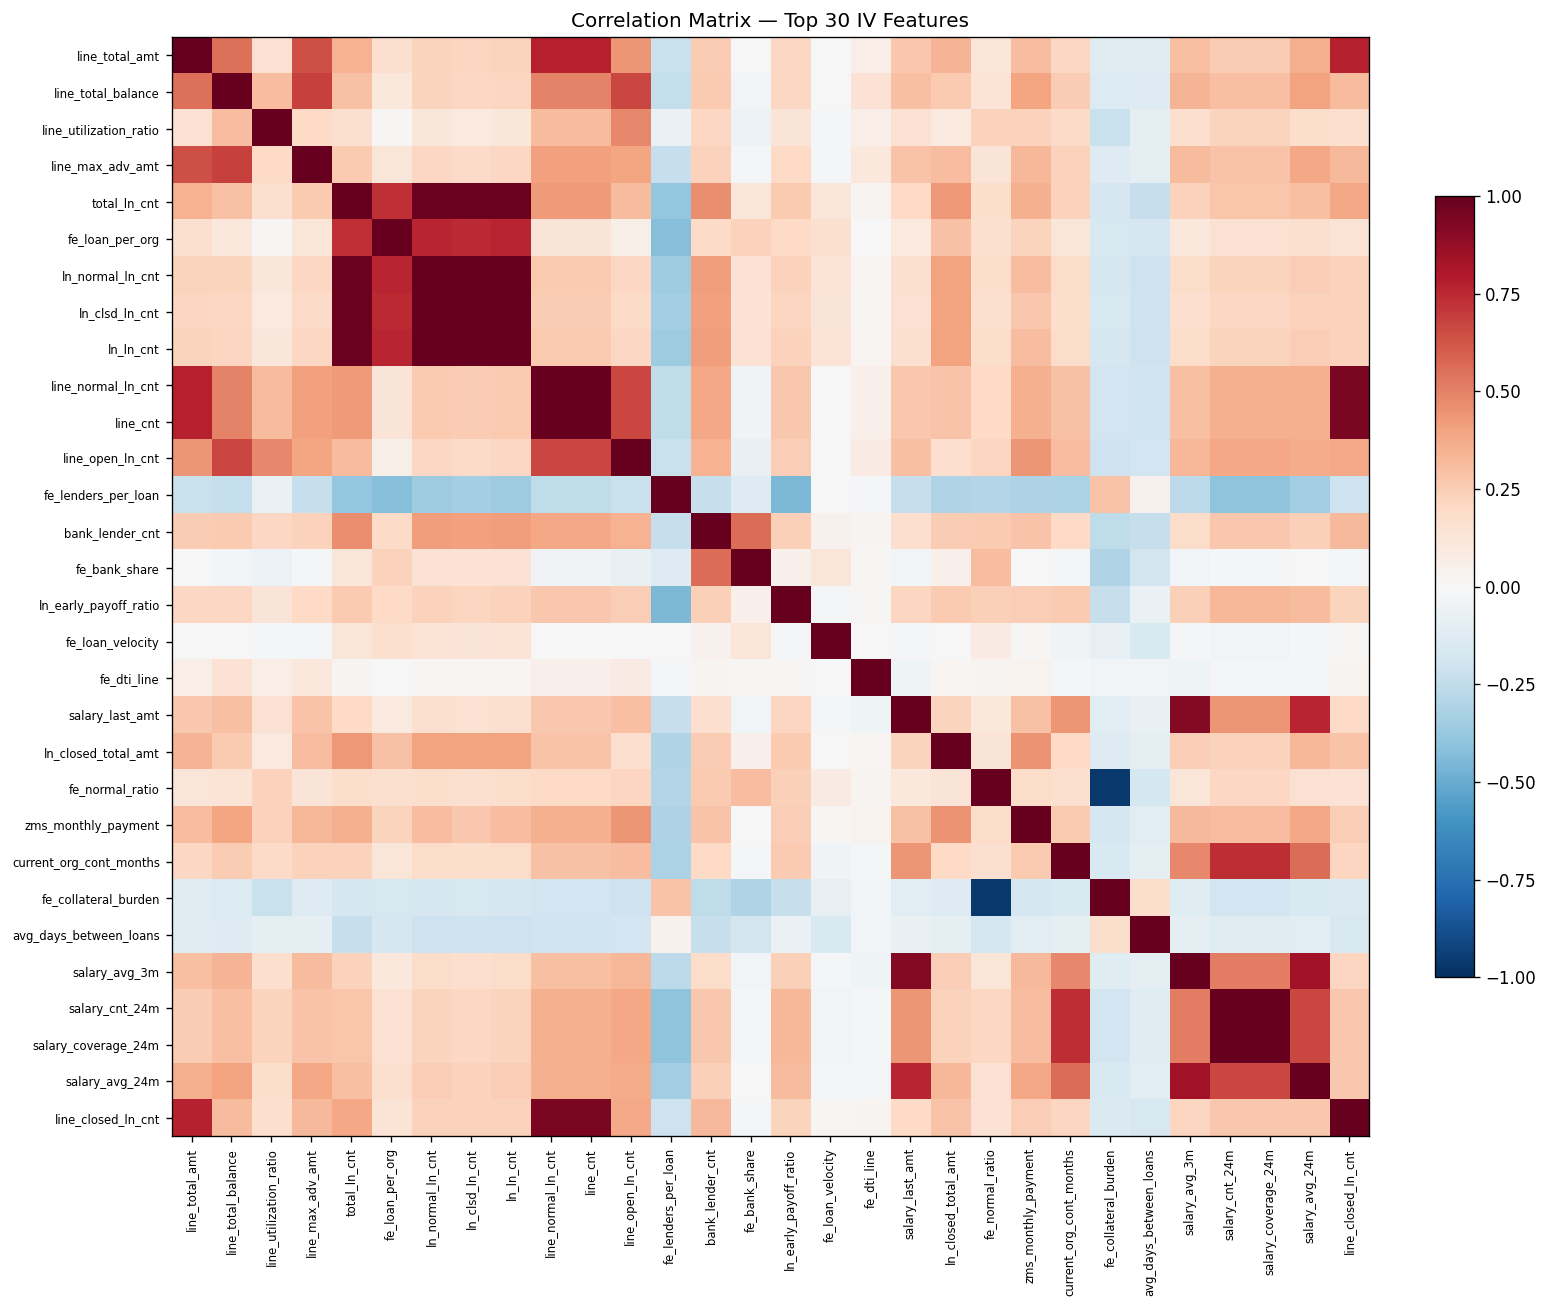

In [13]:
iv_s2 = pd.Series(iv).sort_values(ascending=False)
top30 = [c for c in iv_s2.head(30).index if c in df.columns]
corr = df_train[top30].corr()

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_xticks(range(len(top30))); ax.set_yticks(range(len(top30)))
ax.set_xticklabels(top30, rotation=90, fontsize=7)
ax.set_yticklabels(top30, fontsize=7)
ax.set_title('Correlation Matrix — Top 30 IV Features')
plt.tight_layout(); plt.show()

## 10. Гол дүгнэлт

**Дата.** 39,242 харилцагч (neither хасагдсан), 30+ DPD bad rate ≈ 12.9%.
Сегментүүд: both 27,549 / zms_only 11,587 / hur_only 106.

**Дутуу утга.** Цалингийн бүлэг хувьсагчид ~52% дутуу — энэ нь өөрөө эрсдэлийн
дохио байж болзошгүй (цалингийн мэдээлэлгүй харилцагч). Тиймээс scorecard-д
дутуу утгыг тусдаа bin болгон үлддэг нь зүйтэй.

**Хамгийн хүчтэй ялгах хувьсагчид.** `line_*` (зээлийн шугамын дүн, үлдэгдэл,
ашиглалт), зээлийн тоо, хэвийн/хаасан зээлийн харьцаа. Шинэ `fe_*` хувьсагчдаас
`fe_loan_per_org`, `fe_lenders_per_loan`, `fe_bank_share`, `fe_dti_line` нар IV
шүүлтийг давж, моделд хувь нэмэр оруулж байна.

**Анхаарах.** Корреляц өндөр (multicollinearity) хувьсагчид олон тул scorecard-д
WoE + IV шүүлт, advanced моделд (LightGBM) regularization чухал.

**Дараагийн алхам:** 02 (Scorecard) → 03 (LightGBM сегмент) → 04 (PDO scoring).